In [55]:
import pandas as pd
import utils
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
utils.widen_output(pd)

<module 'pandas' from '/Users/user/code/venv/Dataset-Thesis/lib/python3.11/site-packages/pandas/__init__.py'>

# Re-insert customer_unique_id into the cluster results

In [57]:
df_clean = utils.import_pickle('../05-outlier/rfmd_clean.pkl')
dbscan_clean_result = utils.import_pickle('../15-final/dbscan_clean_result.pkl')

# sanity check
print(f"df_clean row count: {df_clean.shape[0]}")
print(f"dbscan_result row count: {dbscan_clean_result.shape[0]}")
assert df_clean.shape[0] == dbscan_clean_result.shape[0], "Dataframes must have the same number of rows"
# assert if RFM is equal on both dataframes
print("df_clean RFM values:")
print(df_clean.head())
print("dbscan_clean_result RFM values:")
print(dbscan_clean_result.head())
is_equal = (df_clean[['recency', 'frequency', 'monetary']] == dbscan_clean_result[['recency', 'frequency', 'monetary']])
assert is_equal.all().all(), "RFM values must be equal in both dataframes"
print("RFM values are equal in both dataframes")

Importing ../05-outlier/rfmd_clean.pkl
Importing ../15-final/dbscan_clean_result.pkl
df_clean row count: 91393
dbscan_result row count: 91393
df_clean RFM values:
                 customer_unique_id  recency  frequency  monetary      State
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1    141.90  Southeast
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1     27.19  Southeast
2  0000f46a3911fa3c0805444483337064      536          1     86.22      South
3  0000f6ccb0745a6a4b88665a16c9f078      320          1     43.62      North
4  0004aac84e0df4da2b147fca70cf8255      287          1    196.89  Southeast
dbscan_clean_result RFM values:
   recency  frequency  monetary      State  Cluster
0      111          1    141.90  Southeast        0
1      114          1     27.19  Southeast        0
2      536          1     86.22      South        0
3      320          1     43.62      North        0
4      287          1    196.89  Southeast        0
RFM values are equal in both da

In [58]:
customer_clusters = pd.DataFrame(df_clean, columns=['customer_unique_id'])
customer_clusters['cluster'] = dbscan_clean_result['Cluster']
customer_clusters.head()

,customer_unique_id,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0
2,0000f46a3911fa3c0805444483337064,0
3,0000f6ccb0745a6a4b88665a16c9f078,0
4,0004aac84e0df4da2b147fca70cf8255,0


# Re-Preprocessing products, reviews, and payments data

In [59]:
products_raw = utils.import_pickle('../01-preprocessing/products_dataset.pkl')
reviews_raw = utils.import_pickle('../01-preprocessing/order_reviews_dataset.pkl')
payments_raw = utils.import_pickle('../01-preprocessing/order_payments_dataset.pkl')
product_category_name_translation = utils.import_pickle('../01-preprocessing/product_category_name_translation.pkl')

Importing ../01-preprocessing/products_dataset.pkl
Importing ../01-preprocessing/order_reviews_dataset.pkl
Importing ../01-preprocessing/order_payments_dataset.pkl
Importing ../01-preprocessing/product_category_name_translation.pkl


In [60]:
def check_info(title, data):
    print(f"===={title}====")
    print(f"Row count: {data.shape[0]}")
    print("Head:")
    print(data.head())
    print("Info:")
    print(data.info())
    print("Describe:")
    print(data.describe(include='all'))
    print("Null values:")
    print(data.isnull().sum())

In [61]:
check_info("Products Data", products_raw)
check_info("Reviews Data", reviews_raw)
check_info("Payments Data", payments_raw)
check_info("Product Category Name Translation", product_category_name_translation)

====Products Data====
Row count: 32951
Head:
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0  

In [62]:
# format review date
reviews = reviews_raw.copy()
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], format='%Y-%m-%d %H:%M:%S')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], format='%Y-%m-%d %H:%M:%S')
print(reviews.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB
None


In [63]:
# translate product category name
# bravo six, going dark
# but first, assign null name to N/A on product_raw and product_category_name_translation
products_raw['product_category_name'] = products_raw['product_category_name'].fillna('N/A')
# add translation for N/A
product_category_name_translation.loc[71] = ['N/A', 'N/A']
print("Missing values in products_raw:")
print(products_raw.isnull().sum())
# also check for name that doesn't have translation
print("Missing translations in product_category_name_translation:")
products_without_translation = products_raw[~products_raw['product_category_name'].isin(product_category_name_translation['product_category_name'])]
print(products_without_translation['product_category_name'].unique())
# manual translation for missing categories
product_category_name_translation.loc[72] = ['pc_gamer', 'pc_gamer']
product_category_name_translation.loc[73] = ['portateis_cozinha_e_preparadores_de_alimentos', 'kitchen_appliances_and_food_processors']
# now merge
products = pd.merge(products_raw, product_category_name_translation, on='product_category_name', how='left')
# preview the merged data
print(products[['product_id', 'product_category_name', 'product_category_name_english']].head())

Missing values in products_raw:
product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
Missing translations in product_category_name_translation:
['pc_gamer' 'portateis_cozinha_e_preparadores_de_alimentos']
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

  product_category_name_english  
0                     perfumery  
1                           art  
2                sports_leisure  
3                   

# Combine

In [64]:
# to search by id
customers_raw = utils.import_pickle('../01-preprocessing/customers_dataset.pkl')
orders_df = utils.import_pickle('../01-preprocessing/orders_dataset.pkl')
customers_orders = pd.merge(customers_raw, orders_df, on='customer_id', how='right')
# customer_clusters is source of truth as it's already cleaned and clustered
customers_orders_clusters = pd.merge(customers_orders, customer_clusters, on='customer_unique_id', how='right')
master_df = pd.DataFrame(customers_orders_clusters, columns=['order_id', 'customer_unique_id', 'cluster'])
print(master_df.head())

Importing ../01-preprocessing/customers_dataset.pkl
Importing ../01-preprocessing/orders_dataset.pkl
                           order_id                customer_unique_id  cluster
0  e22acc9c116caa3f2b7121bbb380d08e  0000366f3b9a7992bf8c76cfdf3221e2        0
1  3594e05a005ac4d06a72673270ef9ec9  0000b849f77a49e4a4ce2b2a4ca5be3f        0
2  b33ec3b699337181488304f362a6b734  0000f46a3911fa3c0805444483337064        0
3  41272756ecddd9a9ed0180413cc22fb6  0000f6ccb0745a6a4b88665a16c9f078        0
4  d957021f1127559cd947b62533f484f7  0004aac84e0df4da2b147fca70cf8255        0


In [65]:
# # bisa juga pake merge tapi agak gila baca columns sebanyak itu
# merged_df = utils.import_pickle('../01-preprocessing/merged_dataset.pkl')
# merged_df_cluster = pd.merge(merged_df, customer_clusters, on='customer_unique_id', how='right')
# merged_df_cluster_reviews = pd.merge(merged_df_cluster, reviews, on='order_id', how='left')
# merged_df_cluster_reviews_products = pd.merge(merged_df_cluster_reviews, products_raw, on='product_id', how='left')
# merged_df_cluster_reviews_products_translated = pd.merge(merged_df_cluster_reviews_products, product_category_name_translation, on='product_category_name', how='left')

Will use master_df instead

# Top products per cluster

In [66]:
order_items = utils.import_pickle('../01-preprocessing/order_items_dataset.pkl')
order_items_cluster = pd.merge(order_items, master_df, on='order_id', how='right')
products_cluster = pd.merge(order_items_cluster, products, on='product_id', how='left')

Importing ../01-preprocessing/order_items_dataset.pkl


In [67]:
top_categories_per_cluster = products_cluster.groupby('cluster')['product_category_name_english'].value_counts()

for cluster_id in sorted(products_cluster['cluster'].unique()):
    print(f"\n--- Top 3 Categories for Cluster {cluster_id} ---")
    top_3 = top_categories_per_cluster.loc[cluster_id].head(3)
    print(top_3)
    
# bar plot for top 10 categories per cluster
# for cluster_id in sorted(products_cluster['cluster'].unique()):
#     top_10 = top_categories_per_cluster.loc[cluster_id].head(10)
#     plt.figure(figsize=(10, 6))
#     top_10.plot(kind='bar', title=f'Top 10 Categories for Cluster {cluster_id}')
#     plt.xlabel('Category')
#     plt.ylabel('Count')
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()
#     plt.savefig(f'top_10_categories_cluster_{cluster_id}.png', bbox_inches='tight')
# deprecated, see below

utils.export_pickle(products_cluster, 'products_cluster.pkl', False)


--- Top 3 Categories for Cluster -1 ---
product_category_name_english
furniture_decor    44
telephony          41
health_beauty      36
Name: count, dtype: int64

--- Top 3 Categories for Cluster 0 ---
product_category_name_english
health_beauty     7335
bed_bath_table    6902
sports_leisure    6063
Name: count, dtype: int64

--- Top 3 Categories for Cluster 1 ---
product_category_name_english
bed_bath_table     3151
furniture_decor    2719
sports_leisure     1942
Name: count, dtype: int64

--- Top 3 Categories for Cluster 2 ---
product_category_name_english
furniture_decor    32
health_beauty      27
perfumery          20
Name: count, dtype: int64
Saving to products_cluster.pkl


# Review Score per Cluster


--- Average Review Score per Cluster ---
cluster
-1    4.098039
 0    4.210926
 1    3.931959
 2    3.989247
Name: review_score, dtype: float64

--- No review per cluster ---
cluster
-1      5
 0    477
 1    129
 2      2
dtype: int64


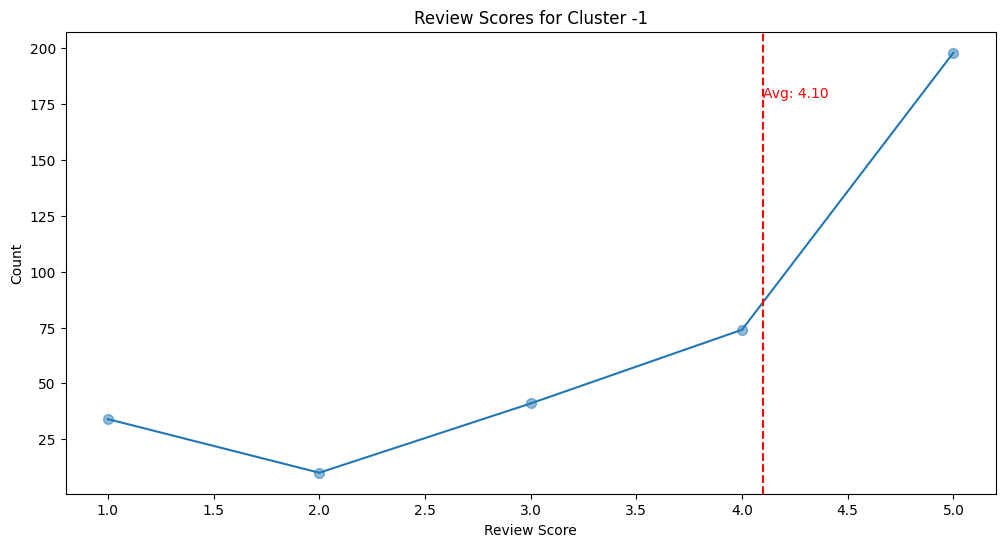

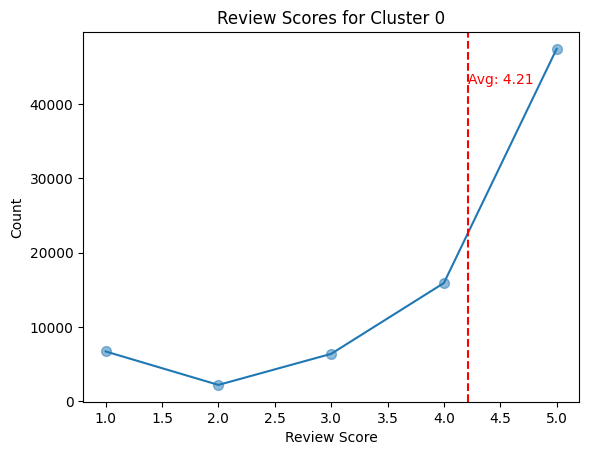

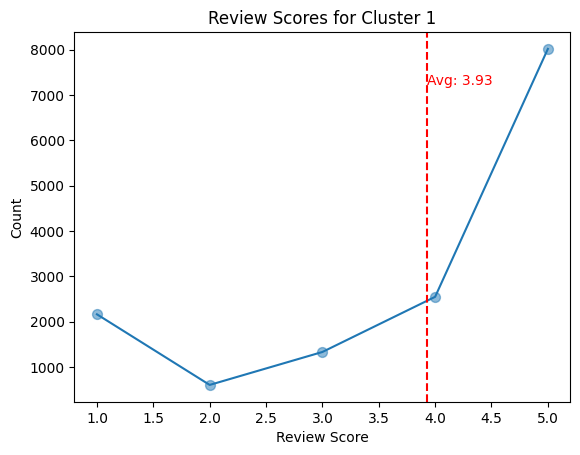

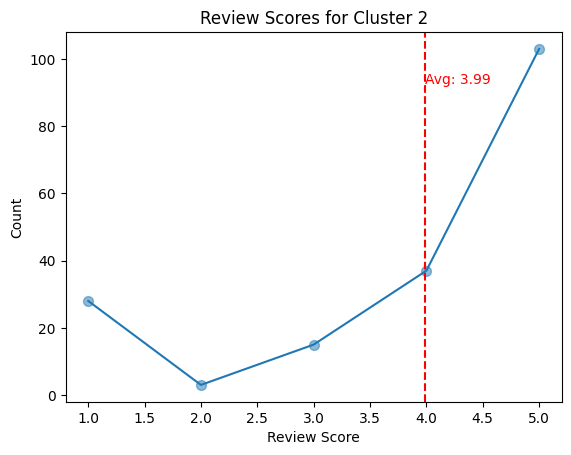

Saving to reviews_with_clusters.pkl


In [68]:
# Merge to link orders/clusters with their reviews
reviews_with_clusters = pd.merge(master_df, reviews, on='order_id', how='left')

# Group by cluster and calculate the average review score
avg_review_score_per_cluster = reviews_with_clusters.groupby('cluster')['review_score'].mean()

# Count the number of order having no review per cluster
no_review_per_cluster = reviews_with_clusters[reviews_with_clusters['review_score'].isnull()].groupby('cluster').size()

print("\n--- Average Review Score per Cluster ---")
print(avg_review_score_per_cluster)

print("\n--- No review per cluster ---")
print(no_review_per_cluster)

# Plotting the distribution of review scores per cluster using line plot
plt.figure(figsize=(12, 6))
plt.tight_layout()
for cluster_id in sorted(reviews_with_clusters['cluster'].unique()):
    cluster_data = reviews_with_clusters[reviews_with_clusters['cluster'] == cluster_id]
    plt.plot(cluster_data['review_score'].value_counts().sort_index(), label=f'Cluster {cluster_id}')
    plt.title(f'Review Scores for Cluster {cluster_id}')
    plt.xlabel('Review Score')
    plt.ylabel('Count')
    plt.scatter(cluster_data['review_score'].value_counts().index, cluster_data['review_score'].value_counts().values, s=50, alpha=0.5)
    avg_score = avg_review_score_per_cluster[cluster_id]
    plt.axvline(avg_score, color='red', linestyle='--', label=f'Avg Score: {avg_score:.2f}')
    plt.text(avg_score, max(cluster_data['review_score'].value_counts().values) * 0.9, f'Avg: {avg_score:.2f}', color='red', fontsize=10)
    # plt.legend()
    plt.savefig(f'review_scores_cluster_{cluster_id}.png', bbox_inches='tight')
    plt.show()


utils.export_pickle(reviews_with_clusters, 'reviews_with_clusters.pkl', False)

In [82]:
avg_review_score_per_cluster = reviews_with_clusters['review_score'].mean()
avg_review_score_per_cluster

np.float64(4.166442609307983)

# Most Used Payment Method per Cluster


--- Most Used Payment Method per Cluster ---
cluster
-1    credit_card
 0    credit_card
 1    credit_card
 2    credit_card
Name: payment_type, dtype: object

--- Detailed Payment Counts per Cluster ---
cluster  payment_type
-1       credit_card       273
         voucher           268
         boleto             48
         debit_card          2
 0       credit_card     60615
         boleto          16120
         debit_card       1287
         voucher           911
 1       credit_card     11621
         boleto           2470
         voucher          2413
         debit_card        174
 2       credit_card       150
         boleto             36
         debit_card          2
Name: count, dtype: int64


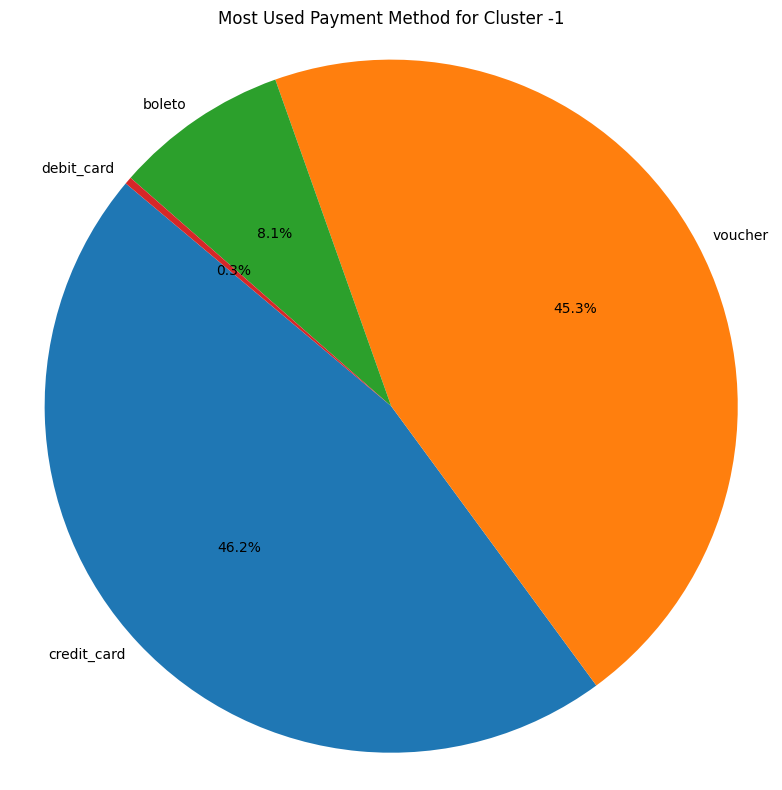

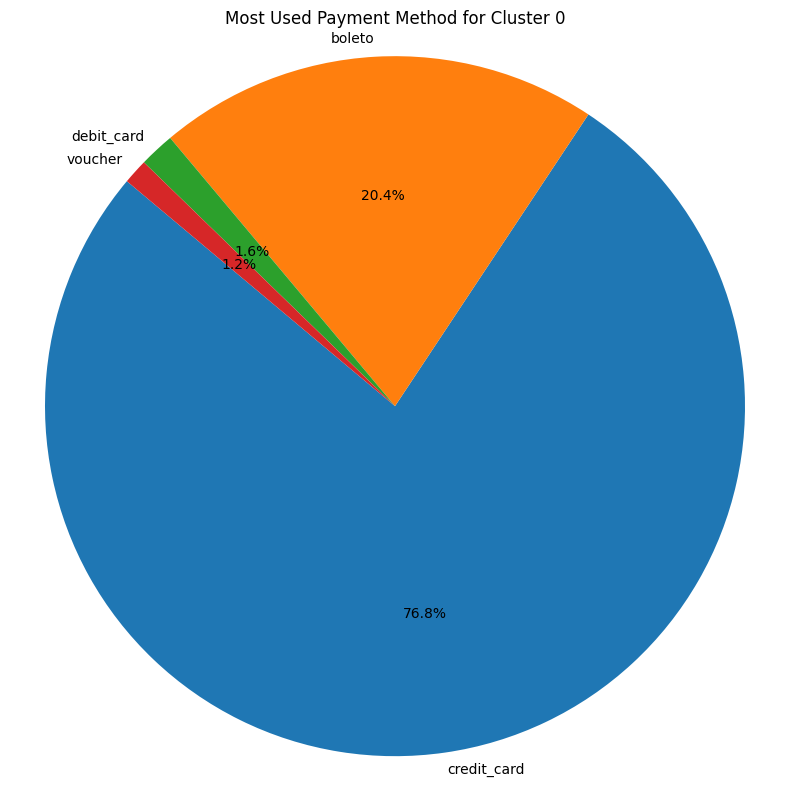

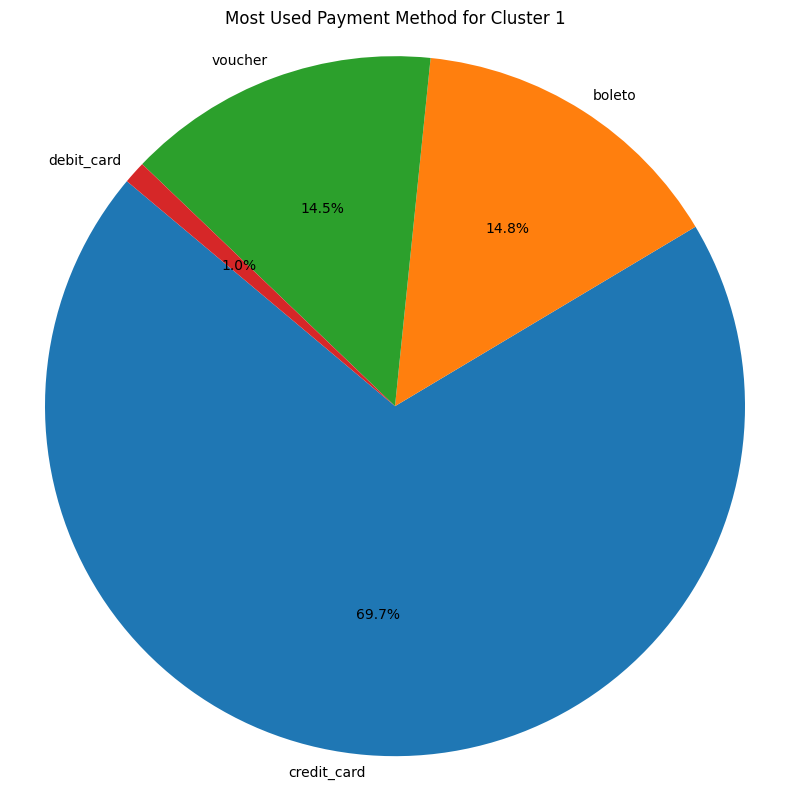

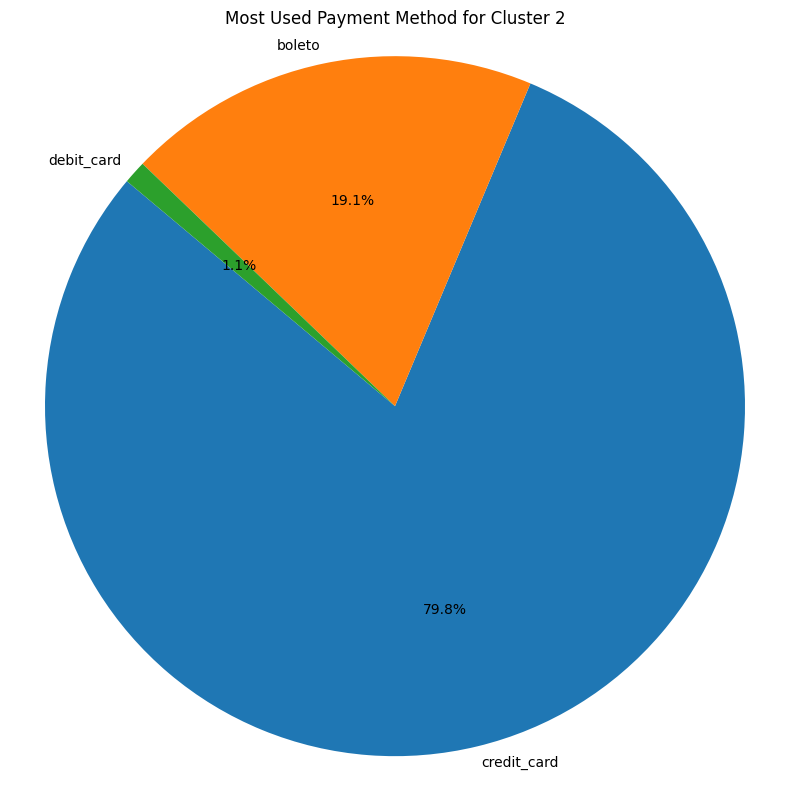

Saving to payments_with_clusters.pkl


In [69]:
# Merge to link orders/clusters with their payment details
payments_with_clusters = pd.merge(master_df, payments_raw, on='order_id', how='left')

# Group by cluster and get the count of each payment type
most_used_payment_per_cluster = payments_with_clusters.groupby('cluster')['payment_type'].agg(lambda x: x.mode()[0])

# Detail payment counts per cluster
payment_counts = payments_with_clusters.groupby('cluster')['payment_type'].value_counts()

print("\n--- Most Used Payment Method per Cluster ---")
print(most_used_payment_per_cluster)

print("\n--- Detailed Payment Counts per Cluster ---")
print(payment_counts)

# Pie chart for most used payment method per cluster
for cluster_id in sorted(payments_with_clusters['cluster'].unique()):
    cluster_data = payments_with_clusters[payments_with_clusters['cluster'] == cluster_id]
    payment_counts = cluster_data['payment_type'].value_counts()
    
    plt.figure(figsize=(8, 8))
    plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, labeldistance=1.05)
    plt.title(f'Most Used Payment Method for Cluster {cluster_id}')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.tight_layout()
    plt.savefig(f'most_used_payment_cluster_{cluster_id}.png', bbox_inches='tight')
    plt.show()

utils.export_pickle(payments_with_clusters, 'payments_with_clusters.pkl', False)

---
mencoba2 lagi

In [81]:
top_3_categories = products_cluster['product_category_name_english'].value_counts().head(3)
top_3_categories

product_category_name_english
bed_bath_table    10066
health_beauty      9052
sports_leisure     8040
Name: count, dtype: int64

/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/2880557705.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_categories.values, y=top_5_categories.index, ax=axes[i], palette='viridis')
/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/2880557705.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_categories.values, y=top_5_categories.index, ax=axes[i], palette='viridis')
/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/2880557705.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.bar

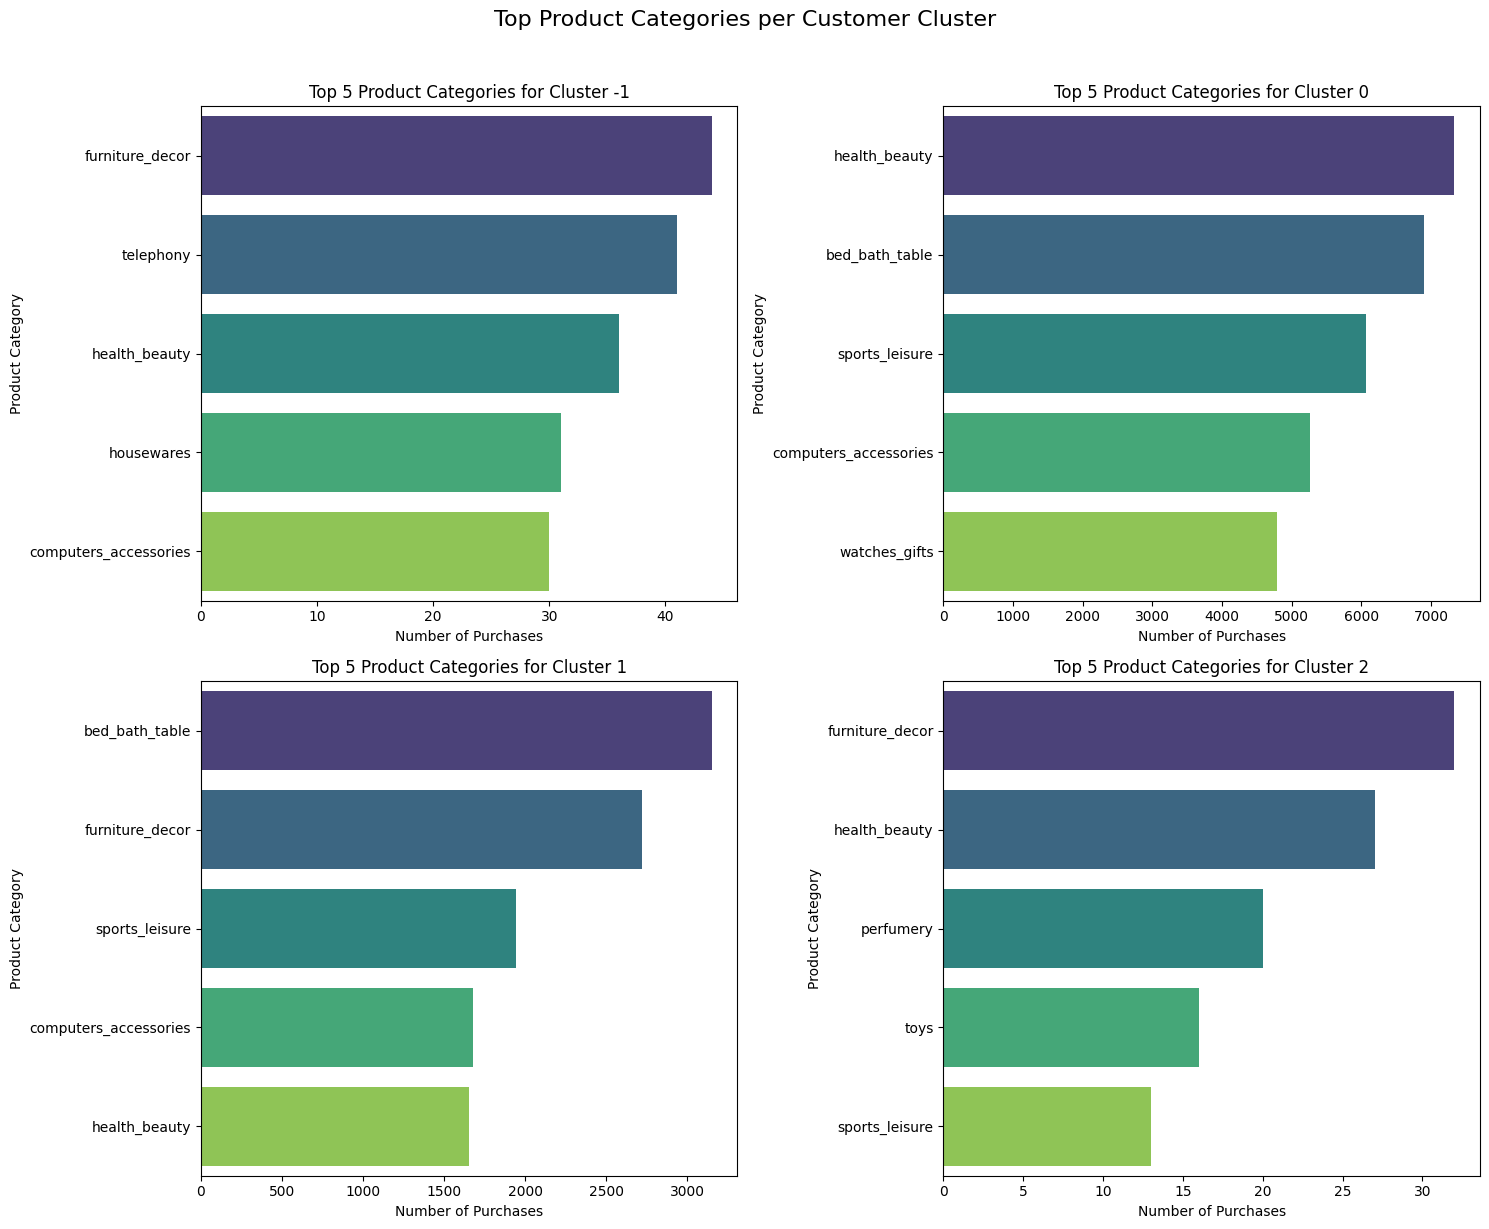

/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/2880557705.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_categories.values, y=top_5_categories.index, ax=ax, palette='viridis')
/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/2880557705.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_categories.values, y=top_5_categories.index, ax=ax, palette='viridis')
/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/2880557705.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top

In [70]:
# Top 5 Product Categories per Cluster
clusters = sorted(products_cluster['cluster'].unique())
num_clusters = len(clusters)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for i, cluster_id in enumerate(clusters):
    cluster_data = products_cluster[products_cluster['cluster'] == cluster_id]

    top_5_categories = cluster_data['product_category_name_english'].value_counts().head(5)

    sns.barplot(x=top_5_categories.values, y=top_5_categories.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 5 Product Categories for Cluster {cluster_id}')
    axes[i].set_xlabel('Number of Purchases')
    axes[i].set_ylabel('Product Category')

plt.suptitle('Top Product Categories per Customer Cluster', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

for i, cluster_id in enumerate(clusters):
    fig, ax = plt.subplots(figsize=(10, 6))
    top_5_categories = products_cluster[products_cluster['cluster'] == cluster_id]['product_category_name_english'].value_counts().head(5)
    sns.barplot(x=top_5_categories.values, y=top_5_categories.index, ax=ax, palette='viridis')
    ax.set_title(f'Top 5 Product Categories for Cluster {cluster_id}')
    ax.set_xlabel('Number of Purchases')
    ax.set_ylabel('Product Category')
    plt.tight_layout()
    plt.savefig(f'top_5_product_categories_cluster_{cluster_id}.png', bbox_inches='tight')
    plt.close(fig)
    

/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/509318402.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='review_score', data=reviews_with_clusters, palette='coolwarm')


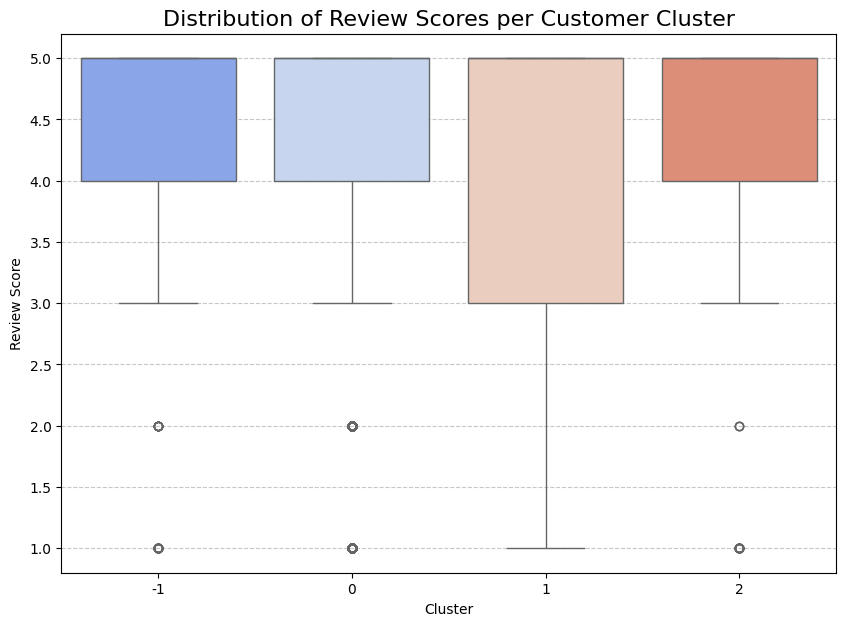

In [71]:
# box plot for review score per cluster
plt.figure(figsize=(10, 7))

sns.boxplot(x='cluster', y='review_score', data=reviews_with_clusters, palette='coolwarm')

plt.title('Distribution of Review Scores per Customer Cluster', fontsize=16)
plt.xlabel('Cluster')
plt.ylabel('Review Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('review_scores_boxplot.png', bbox_inches='tight')

plt.show()

/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/504727795.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='cluster', y='review_score', data=avg_scores, palette='coolwarm')


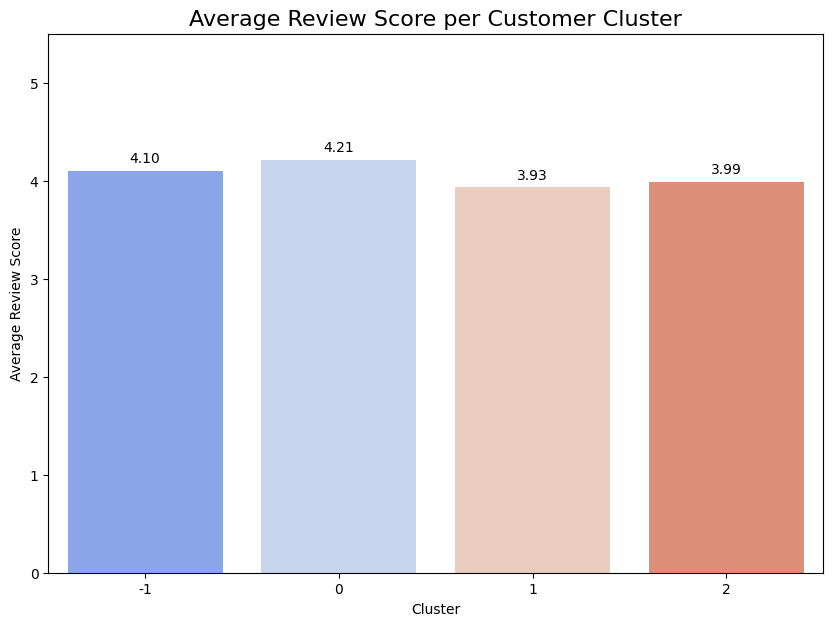

In [72]:
# Bar Chart for Average Review Scores

avg_scores = reviews_with_clusters.groupby('cluster')['review_score'].mean().reset_index()

plt.figure(figsize=(10, 7))
ax = sns.barplot(x='cluster', y='review_score', data=avg_scores, palette='coolwarm')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Average Review Score per Customer Cluster', fontsize=16)
plt.xlabel('Cluster')
plt.ylabel('Average Review Score')
plt.ylim(0, 5.5)
plt.savefig('average_review_scores_barplot.png', bbox_inches='tight')

plt.show()

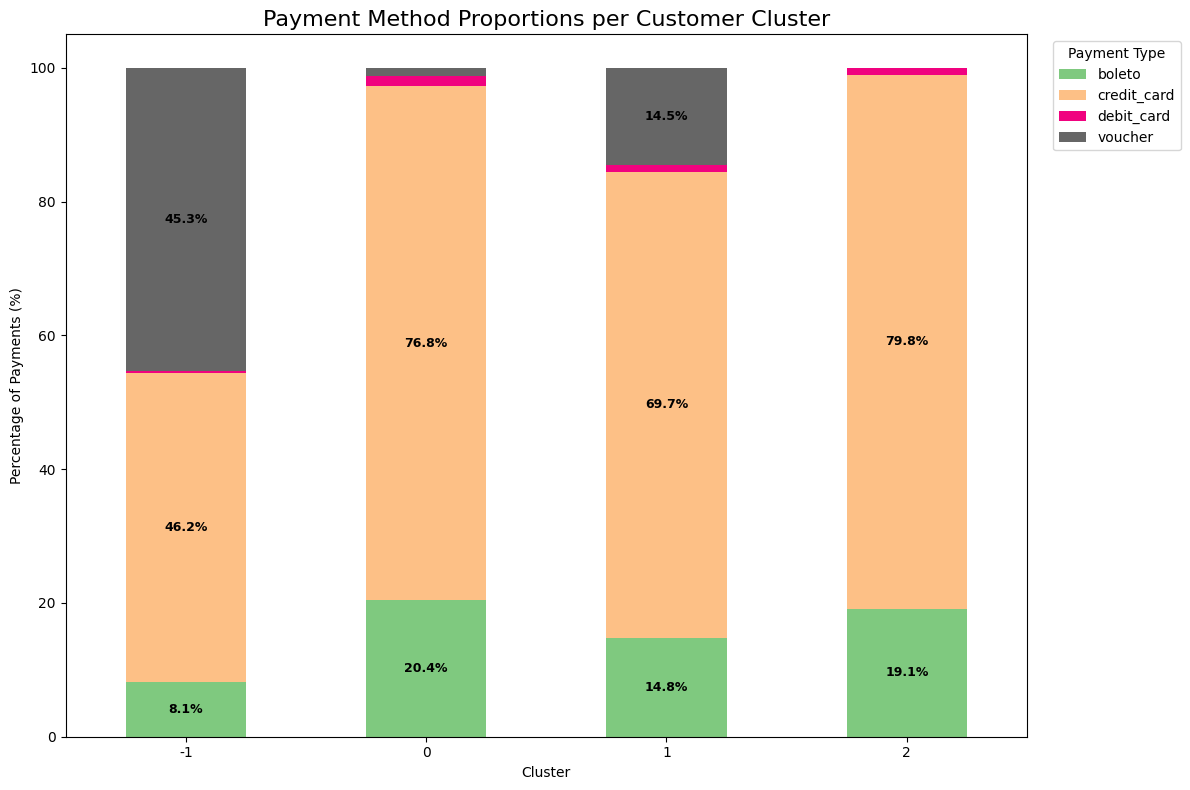

In [75]:
# Stacked Bar Chart for Payment Methods

payment_counts = payments_with_clusters.groupby(['cluster', 'payment_type']).size().unstack(fill_value=0)
payment_percentages = payment_counts.div(payment_counts.sum(axis=1), axis=0) * 100

ax = payment_percentages.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    colormap='Accent'
)

plt.title('Payment Method Proportions per Customer Cluster', fontsize=16)
plt.xlabel('Cluster')
plt.ylabel('Percentage of Payments (%)')
plt.xticks(rotation=0)
plt.legend(title='Payment Type', bbox_to_anchor=(1.02, 1), loc='upper left')

for c in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='black', fontsize=9, fontweight='bold')


plt.tight_layout()
plt.savefig('payment_method_proportions_per_cluster.png', bbox_inches='tight')
plt.show()

In [76]:
customer_clusters_full = dbscan_clean_result.copy()
customer_clusters_full['customer_unique_id'] = df_clean['customer_unique_id']

/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/3572572630.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Cluster', y='recency', data=customer_clusters_full, palette='viridis')
/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/3572572630.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Cluster', y='frequency', data=customer_clusters_full, palette='viridis')
/var/folders/k9/v3jc34ps2qg_01_cfv2rhqsr0000gn/T/ipykernel_5405/3572572630.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns

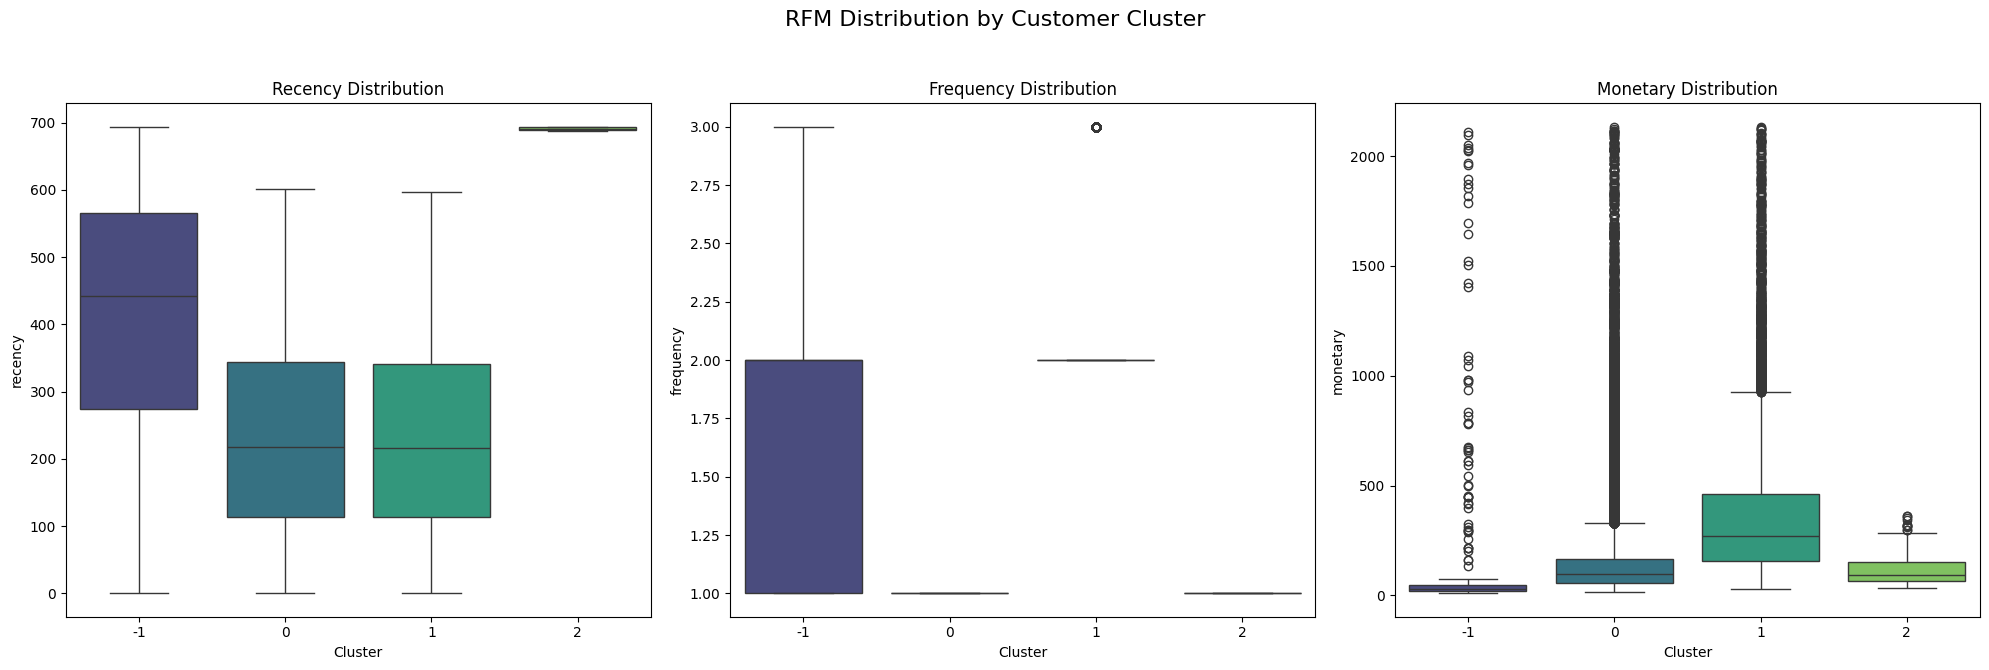

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('RFM Distribution by Customer Cluster', fontsize=16)

sns.boxplot(ax=axes[0], x='Cluster', y='recency', data=customer_clusters_full, palette='viridis')
axes[0].set_title('Recency Distribution')

sns.boxplot(ax=axes[1], x='Cluster', y='frequency', data=customer_clusters_full, palette='viridis')
axes[1].set_title('Frequency Distribution')

sns.boxplot(ax=axes[2], x='Cluster', y='monetary', data=customer_clusters_full, palette='viridis')
axes[2].set_title('Monetary Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

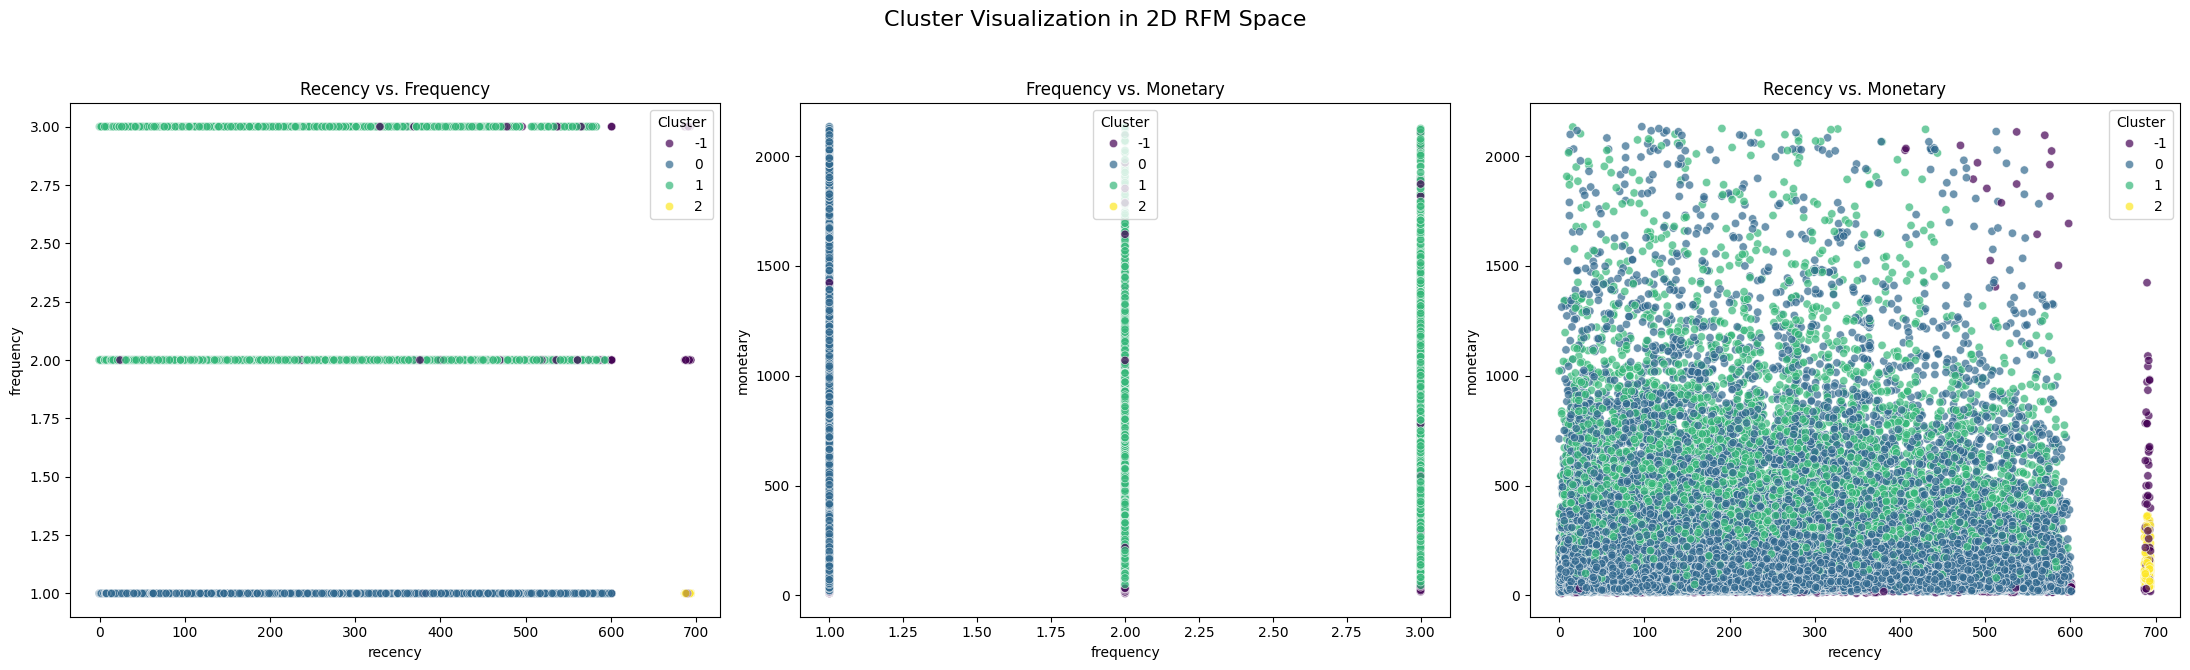

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Cluster Visualization in 2D RFM Space', fontsize=16)
palette = 'viridis'

sns.scatterplot(ax=axes[0], x='recency', y='frequency', data=customer_clusters_full, hue='Cluster', palette=palette, alpha=0.7)
axes[0].set_title('Recency vs. Frequency')

sns.scatterplot(ax=axes[1], x='frequency', y='monetary', data=customer_clusters_full, hue='Cluster', palette=palette, alpha=0.7)
axes[1].set_title('Frequency vs. Monetary')

sns.scatterplot(ax=axes[2], x='recency', y='monetary', data=customer_clusters_full, hue='Cluster', palette=palette, alpha=0.7)
axes[2].set_title('Recency vs. Monetary')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()